In [7]:
# Cell 1: imports

import numpy as np
import pandas as pd
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt


from src.config_subgroups import TreeClusterForestConfig
from src.data_module import load_dataset
from src.cluster_subgroups import (
    discover_subgroups_by_clustering,
    build_subgroup_column,
)
from src.forest_explainer import (
    train_forest_for_subgroup,
    forest_to_rules,
    evaluate_forest,
)
from src.demo_utils import plot_subgroups  # your existing plotting helper


Algorithm overview

We use a two-stage pipeline on tabular data:

Stage 1 – Discover interesting subgroups via clustering

We start from a dataset with features X and a numeric outcome Y.

We standardize X and Y and run KMeans clustering many times, with different random seeds and different numbers of clusters K.

Each cluster is treated as a candidate subgroup. For each candidate we compute a size-corrected exceptionality score based on the KL divergence between the subgroup’s target distribution P(Y | cluster) and the global distribution P(Y).

We then perform a greedy selection step: at each iteration we pick the candidate that maximizes the sum of its size-corrected KL score and a diversity term that favors subgroups whose Y distribution differs from those already selected.

The output is a small number of subgroups (e.g. 5), each represented by a mask over rows and an axis-aligned “box” rule over the original features.

Stage 2 – Explain each subgroup with a random forest

For a given subgroup, we build a one-vs-rest label indicating whether each row belongs to that subgroup.

We split the data into train and validation sets and train many random forests with different random seeds.

For each forest, we measure (i) validation accuracy for predicting subgroup membership and (ii) a complexity measure defined as the average shortest decision-path length on validation samples that belong to the subgroup.

We keep forests with validation accuracy in the top fraction (e.g. top 20%) and select the one with the smallest complexity, breaking ties by accuracy.

Finally, we extract human-readable rules from the selected forest by printing out the individual decision trees.

In [2]:
# Cell 3: instantiate config

cfg = TreeClusterForestConfig()
cfg.datasets


['california']

In [3]:
from sklearn.tree import export_text

def main_rule_for_subgroup(model, feature_names):
    # Take the first tree as a "representative" explanation
    tree = model.estimators_[0]
    text = export_text(tree, feature_names=feature_names)
    return text

In [ ]:
# Cell 4: run pipeline on one dataset

def run_pipeline_on_dataset(name, cfg, save_csv_dir=None):
    print(f"\n=== Dataset: {name} ===")

    X, Y, feature_names, is_clf = load_dataset(name)
    n, d = X.shape
    print(f"Shape: X={X.shape}, Y={Y.shape}, classification={is_clf}")

    # -------- Stage 1: clustering-based subgroup discovery --------
    masks, rules_box, scores = discover_subgroups_by_clustering(
        X, Y, cfg, feature_names=feature_names, n_subgroups=cfg.n_subgroups
    )
    print(f"Selected {len(masks)} subgroups.\n")

    for i, (rule, score) in enumerate(zip(rules_box, scores)):
        print(f"Subgroup {i}: score={score:.4f}")
        print(f"  Rule: {rule}\n")

    subgroup_id = build_subgroup_column(masks, n_samples=n, fill_value=-1)

    df = pd.DataFrame(X, columns=feature_names)
    df["target"] = Y
    df["subgroup_id"] = subgroup_id

    if save_csv_dir is not None:
        import os
        os.makedirs(save_csv_dir, exist_ok=True)
        out_path = f"{save_csv_dir}/{name}_with_subgroups.csv"
        df.to_csv(out_path, index=False)
        print(f"Saved {out_path}")

    

    # -------- Stage 2: explain each subgroup with a random forest --------
    subgroup_models = []
    # for k, mask in enumerate(masks):
    #     print(f"\n--- Explaining subgroup {k} (size={mask.sum()}) ---")
    #     model, candidates = train_forest_for_subgroup(X, mask, cfg)
    #     if model is None:
    #         print("Subgroup too small to fit a stable model.")
    #         continue

    #     acc_all, comp_all = evaluate_forest(model, X, mask)
    #     print(f"Selected forest: accuracy={acc_all:.3f}, avg path length={comp_all:.2f}")

    #     rules_txt = forest_to_rules(model, feature_names, max_trees=2)
    #     for text in rules_txt:
    #         print(text)
    #         print("-" * 60)

    #     subgroup_models.append((k, model))
    rules_rf = []
    for k, mask in enumerate(masks):
        model_k, _ = train_forest_for_subgroup(X, mask, cfg)
        if model_k is None:
            rules_rf.append(f"Subgroup {k}")
        else:
            rules_rf.append(main_rule_for_subgroup(model_k, feature_names))

        best_tree = model_k.estimators_[0]   # take the first tree as representative

        # 2) Text explanation (like in the Colab)
        print("\nText tree explanation for this subgroup:")
        tree_text = export_text(best_tree, feature_names=feature_names)
        print(tree_text)

        # 3) Optional: plot the tree nicely
        plt.figure(figsize=(10, 6))
        plot_tree(
            best_tree,
            feature_names=feature_names,
            class_names=["not in subgroup", "in subgroup"],
            filled=True,
            rounded=True,
            fontsize=8,
        )
        plt.title(f"Explanation tree for subgroup {k}")
        plt.show()
    # Optional: visualize the target distributions of first few subgroups
    if len(masks) > 0:
        print("Plotting target distributions of first few subgroups...")
        plot_subgroups(
            target=Y,
            subgroups=masks,
            rules=rules_rf,
            which_sgs=list(range(min(3, len(masks)))),
        )

    return df, subgroup_models



=== Dataset: california ===
Shape: X=(20640, 8), Y=(20640,), classification=False
Selected 5 subgroups.

Subgroup 0: score=1.2177
  Rule: 2 < HouseAge < 52 ∧ 1.825 < AveRooms < 141.9 ∧ 0.5 < AveBedrms < 25.64 ∧ 13 < Population < 7431 ∧ 1.275 < AveOccup < 41.21 ∧ 32.68 < Latitude < 38.91 ∧ -122.7 < Longitude < -116.4

Subgroup 1: score=45.5328
  Rule: 0.8462 < AveRooms < 132.5 ∧ 0.4444 < AveBedrms < 34.07 ∧ 6 < Population < 3.568e+04

Subgroup 2: score=41.2340
  Rule: 0.536 < MedInc < 15 ∧ 1.13 < AveRooms < 56.27 ∧ 0.3333 < AveBedrms < 11.41 ∧ 3 < Population < 1.612e+04 ∧ 0.75 < AveOccup < 502.5 ∧ 32.56 < Latitude < 40.63 ∧ -123.8 < Longitude < -114.6

Subgroup 3: score=29.7014
  Rule: 0.8462 < AveRooms < 132.5 ∧ 0.4444 < AveBedrms < 34.07 ∧ 6 < Population < 3.568e+04

Subgroup 4: score=32.1559
  Rule: 1.13 < AveRooms < 141.9 ∧ 0.3333 < AveBedrms < 25.64 ∧ 3 < Population < 1.612e+04 ∧ 0.75 < AveOccup < 502.5 ∧ 32.56 < Latitude < 40.63 ∧ -123.8 < Longitude < -114.6

Saved outputs_subgro

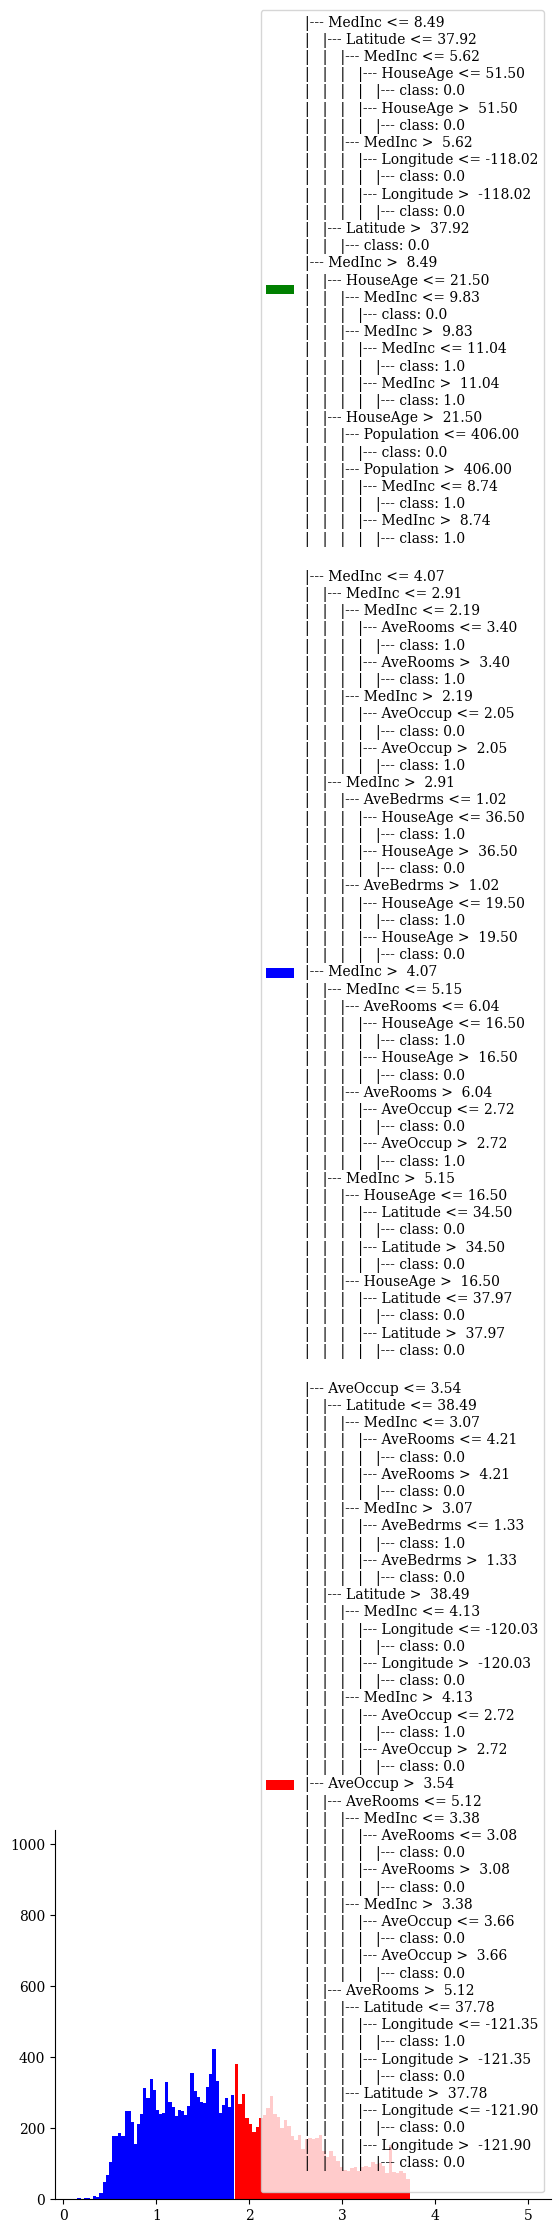

In [6]:
# Cell 5: loop over datasets

all_results = {}

for name in cfg.datasets:
    df, models = run_pipeline_on_dataset(name, cfg, save_csv_dir="outputs_subgroups")
    all_results[name] = {"df": df, "models": models}


In [ ]:
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt
